# Asian option variance reduction

Author: Fred J. Hickernell

This companion to the generating-samples notebook compares importance sampling, a European-call control variate, their combination, and randomized low discrepancy points for the same Asian-call price.

Run with the course `qmcpy` kernel, or open a private working copy in Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/performance/AsianOptionVarianceReduction.ipynb)

In Colab, run the setup cell once and then continue in order. Save a copy in Drive to keep your changes.

$\newcommand{\vX}{\boldsymbol{X}}$

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

## Asian call and sampling map

Under the risk-neutral geometric Brownian model, $S(t)=S_0\exp\{(r-\sigma^2/2)t+\sigma B(t)\}$. The discounted payoff is $e^{-rT}(d^{-1}\sum_{j=1}^d S(t_j)-K)_+$. QMCPy’s `BrownianMotion` supplies the uniform-to-path map developed in **Generating Samples**. We use its Cholesky construction to retain the chronological-increment interpretation. The variance-reduction methods below change the integrand while preserving its expectation.
Let $\boldsymbol X=(B(t_1),\ldots,B(t_d))\sim\operatorname{Norm}(\boldsymbol0,\mathsf\Sigma)$ be the target Brownian path, with $\Sigma_{jk}=\min(t_j,t_k)$. The function $f$ builds asset prices and returns the discounted Asian payoff, so $Y=f(\boldsymbol X)$ and $\mu=\mathbb E(Y)$.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qmcpy as qp

%matplotlib inline

S0, K, r, sigma, T, d = 80.0, 100.0, 0.03, 0.7, 1.0, 13
dt = T/d
times = dt*np.arange(1, d+1)
option_params = dict(start_price=S0, strike_price=K, interest_rate=r,
                     volatility=sigma, t_final=T, decomp_type="Cholesky")

def weighted_payoffs(w, theta=0.0):
    shifted_w = w + theta*times
    stock = S0*np.exp((r-sigma*sigma/2)*times + sigma*shifted_w)
    likelihood = np.exp(-theta*w[..., -1]-theta*theta*T/2)
    asian = np.exp(-r*T)*np.maximum(stock.mean(axis=-1)-K, 0)*likelihood
    european = np.exp(-r*T)*np.maximum(stock[..., -1]-K, 0)*likelihood
    return np.stack([asian, european])

# QMCPy transforms cube points to Brownian paths before evaluating the payoffs.
payoff_integrand = qp.CustomFun(
    qp.BrownianMotion(qp.IIDStdUniform(d), t_final=T, decomp_type="Cholesky"),
    g=weighted_payoffs, dimension_indv=(2,))

def payoffs(u, theta=0.0):
    asian, european = payoff_integrand.f(u, theta=theta)
    return asian, european

european_option = qp.FinancialOption(qp.IIDStdUniform(d),
                                     option="EUROPEAN", **option_params)
european_mean = european_option.get_exact_value()
print(f"Known European-call mean: {european_mean:.6f}")


Known European-call mean: 16.578974


## Importance sampling and a control variate

Choose the drifted proposal $\boldsymbol Z\sim\operatorname{Norm}(\boldsymbol a,\mathsf\Sigma)$, where $a_j=\theta t_j$. Its weight and alternative contribution are
\begin{align*}
w(\boldsymbol z)&=\exp\{-\theta z_d+\theta^2T/2\},\\
g_{\mathrm{IS}}(\boldsymbol z)&=f(\boldsymbol z)w(\boldsymbol z),\qquad
\mathbb E_{\mathrm{prop}}[g_{\mathrm{IS}}(\boldsymbol Z)]=\mu.
\end{align*}
The code constructs $Z(t)=B(t)+\theta t$ from a zero-drift Brownian path. Thus $z_d=B(T)+\theta T$ and the same weight is $\exp\{-\theta B(T)-\theta^2T/2\}$. These are the same likelihood ratio evaluated in two coordinate conventions.

For controls, write $c(\boldsymbol x)$ for the European-call payoff and $\eta_1(\boldsymbol x)=c(\boldsymbol x)-\mathbb E_{\mathrm{tar}}[c(\boldsymbol X)]$. Subtract $\beta\eta_1(\boldsymbol X)$ from $Y$, choosing $\beta$ with a **separate pilot sample**. Under drift, use the weighted European payoff minus its target mean as the zero-mean control. The same likelihood ratio applies to both payoffs.


Here importance sampling uses the identity map with a nonconstant correction $w_T=w$. The inverse-normal/Brownian construction generates the drifted proposal as $\boldsymbol Z=\boldsymbol S_\theta(\boldsymbol U)$; the cube integrand is $h_\theta=g_{\mathrm{IS}}\circ\boldsymbol S_\theta$. With zero drift, this construction is an exact transport to the target: $w_T=1$ and $g_{\mathrm{ET}}=f\circ\boldsymbol S_0$. These roles match Deck 04; the code's `payoffs(u, theta)` returns the composed, weighted contributions on uniform inputs.

In [3]:
pilot=qp.IIDStdUniform(d, seed=2026)(2**14)
def pilot_beta(theta):
    a,c=payoffs(pilot,theta)
    return np.cov(a,c,ddof=1)[0,1]/np.var(c,ddof=1)

for theta in [0.0,1.0]:
    print(f"pilot beta for theta={theta:g}: {pilot_beta(theta):.4f}")

pilot beta for theta=0: 0.3811
pilot beta for theta=1: 0.3476


## Compare independent replications

Each estimate uses the same number of main samples. The empirical standard deviation across replications measures estimator variability; randomized Sobol points are independent across replications.

In [4]:
n, repetitions=2**10,24
theta_val = 1.5
methods=[("IID",0.0,False,False),
         ("IID + drift",theta_val,False,False),
         ("IID + control",0.0,True,False),
         ("IID + both",theta_val,True,False),
         ("randomized Sobol",0.0,False,True)]
results={}
for name,theta,use_cv,use_sobol in methods:
    beta=pilot_beta(theta) if use_cv else 0.0
    estimates=[]
    for rep in range(repetitions):
        seed=565+rep
        u=(qp.DigitalNetB2(d, seed=seed)(n) if use_sobol
           else qp.IIDStdUniform(d, seed=seed)(n))
        asian,european=payoffs(u,theta)
        estimates.append(np.mean(asian-beta*(european-european_mean)))
    results[name]=np.array(estimates)
print("method                mean price    replication SD")
for name,values in results.items():
    print(f"{name:21s} {values.mean():10.5f} {values.std(ddof=1):16.5f}")
assert all(np.all(np.isfinite(v)) for v in results.values())

method                mean price    replication SD
IID                      7.57445          0.58536
IID + drift              7.71590          0.23019
IID + control            7.60187          0.20952
IID + both               7.73557          0.22755
randomized Sobol         7.68526          0.11303


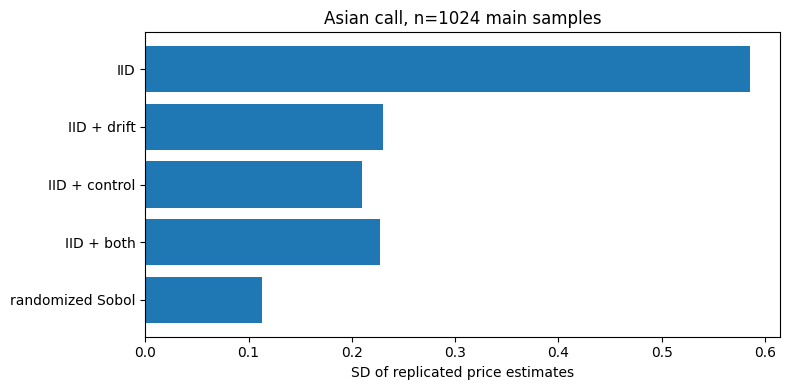

In [5]:
fig,ax=plt.subplots(figsize=(8,4))
names=list(results)
sd=[results[name].std(ddof=1) for name in names]
ax.barh(names,sd)
ax.invert_yaxis()
ax.set(xlabel="SD of replicated price estimates",title=f"Asian call, n={n} main samples")
fig.tight_layout()

Drift, a control variate, and randomized Sobol sampling address different sources of error. The particular drift and control coefficient can be tuned with a pilot; the performance shown here is for this one option and sample size. The pilot work is additional to the main-sample cost.

## A lookback call on the same paths

A floating-strike lookback call pays $S(T)-\min_{0\le j\le d}S(t_j)$, with $t_0=0$ included. Here the minimum is over the **13 monitoring dates and the initial price**, so this is a discretely monitored lookback option. It illustrates a path-dependent payoff without changing the Brownian path generator. The resulting price is for this monitoring schedule; continuous monitoring has a different value.

QMCPy’s `FinancialOption(option="LOOKBACK")` composes the same Cholesky Brownian construction, asset-price map, and discounted payoff. Its minimum includes the initial price. Both the IID and randomized Sobol' samples come from QMCPy.


In [6]:
lookback_option = qp.FinancialOption(qp.IIDStdUniform(d),
                                     option="LOOKBACK", **option_params)

lookback_results = {}
for label in ["IID", "randomized Sobol"]:
    prices = []
    for rep in range(repetitions):
        seed = 3320+rep
        sampler = (qp.IIDStdUniform(d, seed=seed) if label == "IID"
                   else qp.DigitalNetB2(d, seed=seed))
        prices.append(lookback_option.f(sampler(n)).mean())
    lookback_results[label] = np.asarray(prices)
for label, prices in lookback_results.items():
    print(f"{label:17s}: lookback price {prices.mean():.5f}, replication SD {prices.std(ddof=1):.5f}")
assert all(np.all(np.isfinite(v)) for v in lookback_results.values())


IID              : lookback price 31.56923, replication SD 1.21269
randomized Sobol : lookback price 31.74509, replication SD 0.43798


## Stop when the price uncertainty meets a tolerance

Use the existing discounted payoff and a European-call control coefficient fitted on the **separate pilot** above. The coefficient stays fixed throughout the main run. Independent randomized Sobol' replications provide an approximate Student-$t$ interval for the average price. We stop when its reported half-width is at most $\varepsilon=0.10$ price units, or the main-sample budget is exhausted. No exact Asian-option price is used.

For drift $\theta=1$, the cube contribution is
\begin{align*}
h_{\theta,\beta}(\boldsymbol u)
&=g_{\mathrm{IS}}(\boldsymbol S_\theta(\boldsymbol u))
-\beta\bigl[c(\boldsymbol S_\theta(\boldsymbol u))w(\boldsymbol S_\theta(\boldsymbol u))
-\mathbb E_{\mathrm{tar}}[c(\boldsymbol X)]\bigr].
\end{align*}
The control has mean zero, so this still estimates the original price. Total work includes the pilot in addition to all 32 main replications. The interval concerns **simulation error for this fixed 13-date model**. It does not measure model uncertainty, parameter uncertainty, or error from replacing continuous monitoring with discrete dates.

As in the [Keister stopping comparison](../applications/KeisterExample.ipynb#Practical-stopping-criteria), the replication interval is approximate, and its nominal coverage does not automatically hold after adaptive stopping.

In [7]:
import warnings
from IPython.display import display, Markdown

price_tolerance = 0.10
price_budget = 2**18
theta_stopping = 1.0
beta_stopping = pilot_beta(theta_stopping)

def controlled_cube_payoff(u):
    # QMCPy supplies (..., d), including a leading replication axis.
    asian, european = payoffs(u, theta_stopping)
    return asian-beta_stopping*(european-european_mean)

price_integrand = qp.CustomFun(
    qp.Uniform(qp.DigitalNetB2(d, seed=5650, replications=32)),
    g=controlled_cube_payoff)
price_rule = qp.CubQMCRepStudentT(price_integrand, abs_tol=price_tolerance,
                                rel_tol=0, n_limit=price_budget, alpha=0.01)
with warnings.catch_warnings(record=True) as price_messages:
    warnings.simplefilter("always")
    price_solution, price_data = price_rule.integrate()
price_estimate = float(np.asarray(price_solution).item())
price_low = float(np.asarray(price_data.comb_bound_low).item())
price_high = float(np.asarray(price_data.comb_bound_high).item())
price_radius = max(price_estimate-price_low, price_high-price_estimate)
price_decision = "tolerance met" if price_radius <= price_tolerance else "not met"
pilot_count = len(pilot)
display(Markdown(
    f"| Tolerance | Price estimate | Approximate interval | Radius | Main samples | Pilot samples | Total | Decision |\n"
    f"|--:|--:|:--|--:|--:|--:|--:|:--|\n"
    f"| {price_tolerance:.2f} | {price_estimate:.5f} | [{price_low:.5f}, {price_high:.5f}] | "
    f"{price_radius:.5f} | {int(price_data.n_total):,} | {pilot_count:,} | "
    f"{int(price_data.n_total)+pilot_count:,} | {price_decision} |"))
for message in price_messages:
    print(f"{message.category.__name__}: {str(message.message).strip()}")
assert np.isfinite(price_estimate) and price_low <= price_estimate <= price_high
assert int(price_data.n_total) == 32*int(np.asarray(price_data.n_rep).item())


| Tolerance | Price estimate | Approximate interval | Radius | Main samples | Pilot samples | Total | Decision |
|--:|--:|:--|--:|--:|--:|--:|:--|
| 0.10 | 7.66388 | [7.59135, 7.73640] | 0.07252 | 16,384 | 16,384 | 32,768 | tolerance met |

**Explore:** request `price_tolerance = 0.01`, or reduce `price_budget`, and compare the reported decision and total work. A budget stop is not evidence that the tolerance was met. The fitted pilot is additional work; rerunning with new pilot data changes the coefficient and can change efficiency.

In [8]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 1.4 sec.
